# Section 4 – Weather Cancellation Analyzer

This analysis combines hotel booking data with historical weather information from Open-Meteo to examine whether rainfall or temperature is associated with cancellations and no-shows.

### Import Libraries

Load the packages required for data preparation, API requests, and visualization.

In [12]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

### Load Dataset

Load the booking dataset and preserve the loyalty tier value "None" as a valid category.

In [15]:
csv_path = "hotel_bookings (1).csv"

df = pd.read_csv(csv_path, keep_default_na=False)

print("Original rows:", len(df))
df.head()

Original rows: 12000


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,424,Customer_424,Group,2023-07-03,Manali,Platinum,38,Crimson Courtyard,Manali,...,4,OTA,5808.46,0.00,NONE,46467.68,Debit Card,Cancelled,,
1,100001,239,Customer_239,Individual,2022-07-18,Jaipur,None,32,Saffron Palace,Pune,...,4,Corporate Portal,4021.62,0.00,,16086.48,Net Banking,Cancelled,,
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,,
3,100003,722,Customer_722,Individual,2022-11-07,Udaipur,None,43,Indigo Lodge,Bangalore,...,3,OTA,5885.85,0.00,NONE,17657.55,Credit Card,No-Show,,
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,...,7,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21


### Convert Date Columns

Convert stay dates into datetime format for filtering and analysis.

In [16]:
# Converting stay dates to datetime
df["checkin_date"] = pd.to_datetime(df["checkin_date"], errors="coerce")
df["checkout_date"] = pd.to_datetime(df["checkout_date"], errors="coerce")

### Prepare Analysis Dataset

Create a working dataset by removing invalid records and keeping only Goa and Manali bookings with 2024 check-in dates.

In [17]:
# Creating the working dataframe required for Section 4
working_df = df[
    (df["checkout_date"] > df["checkin_date"])
    & (df["num_rooms"] > 0)
    & (df["booking_status"].isin(["Completed", "Cancelled", "No-Show"]))
    & (df["property_city"].isin(["Goa", "Manali"]))
    & (df["checkin_date"].dt.year == 2024)
].copy()

# Reset the index after filtering
working_df = working_df.reset_index(drop=True)

print("Rows in the Section 4 working dataframe:", len(working_df))
print()
print("Bookings by city:")
print(working_df["property_city"].value_counts())
print()
print("Bookings by status:")
print(working_df["booking_status"].value_counts())

Rows in the Section 4 working dataframe: 1582

Bookings by city:
property_city
Goa       876
Manali    706
Name: count, dtype: int64

Bookings by status:
booking_status
Completed    1163
Cancelled     378
No-Show        41
Name: count, dtype: int64


### Create City-Date Keys

Generate unique city and check-in date combinations to reduce the number of API requests.

In [18]:
# Creating one row for each unique city and check in date
unique_city_dates = (
    working_df[["property_city", "checkin_date"]]
    .drop_duplicates()
    .sort_values(["property_city", "checkin_date"])
    .reset_index(drop=True)
)

print("Unique city-date combinations:", len(unique_city_dates))
unique_city_dates.head()

Unique city-date combinations: 649


,property_city,checkin_date
0,Goa,2024-01-01
1,Goa,2024-01-02
2,Goa,2024-01-03
3,Goa,2024-01-04
4,Goa,2024-01-05


### Define Coordinates and API Settings

Map each city to coordinates and configure the Open-Meteo API request parameters.

In [20]:
# Manual coordinate mapping
coordinates = {
    "Goa": {
        "latitude": 15.2993,
        "longitude": 74.1240
    },
    "Manali": {
        "latitude": 32.2396,
        "longitude": 77.1887
    }
}

# Open-Meteo Historical Weather API endpoint
api_url = "https://archive-api.open-meteo.com/v1/era5"

# This list will store the weather records returned by the API
weather_frames = []

### Fetch Historical Weather Data

Retrieve daily rainfall and maximum temperature data for Goa and Manali. Basic error handling is included to prevent failures from stopping the analysis.

In [21]:
# Requesting the required date range separately for Goa and Manali
for city in ["Goa", "Manali"]:

    # Find the first and last required dates for this city
    city_dates = unique_city_dates[
        unique_city_dates["property_city"] == city
    ].copy()

    start_date = city_dates["checkin_date"].min().strftime("%Y-%m-%d")
    end_date = city_dates["checkin_date"].max().strftime("%Y-%m-%d")

    # Parameters sent to Open-Meteo
    params = {
        "latitude": coordinates[city]["latitude"],
        "longitude": coordinates[city]["longitude"],
        "start_date": start_date,
        "end_date": end_date,
        "daily": "precipitation_sum,temperature_2m_max",
        "timezone": "Asia/Kolkata"
    }

    try:
        # timeout prevents the notebook from waiting forever
        response = requests.get(api_url, params=params, timeout=30)

        if response.status_code == 200:
            api_data = response.json()
            daily_data = api_data.get("daily", {})

            # Read the daily arrays safely
            date_values = daily_data.get("time", [])
            rain_values = daily_data.get("precipitation_sum", [])
            temperature_values = daily_data.get("temperature_2m_max", [])

            # Check that the API returned matching daily data
            if (
                len(date_values) > 0
                and len(date_values) == len(rain_values)
                and len(date_values) == len(temperature_values)
            ):
                city_weather = pd.DataFrame({
                    "property_city": city,
                    "checkin_date": date_values,
                    "precipitation_sum": rain_values,
                    "temperature_2m_max": temperature_values,
                    "api_status": "Success"
                })
            else:
                # Create missing rows instead of stopping the notebook
                city_weather = city_dates.copy()
                city_weather["precipitation_sum"] = pd.NA
                city_weather["temperature_2m_max"] = pd.NA
                city_weather["api_status"] = "Missing weather data"

        else:
            # Handle non-success HTTP responses
            city_weather = city_dates.copy()
            city_weather["precipitation_sum"] = pd.NA
            city_weather["temperature_2m_max"] = pd.NA
            city_weather["api_status"] = "HTTP " + str(response.status_code)

    except requests.exceptions.Timeout:
        # Handle requests that exceed the timeout
        city_weather = city_dates.copy()
        city_weather["precipitation_sum"] = pd.NA
        city_weather["temperature_2m_max"] = pd.NA
        city_weather["api_status"] = "Timeout"

    except requests.exceptions.RequestException as error:
        # Handle connection and other request errors
        city_weather = city_dates.copy()
        city_weather["precipitation_sum"] = pd.NA
        city_weather["temperature_2m_max"] = pd.NA
        city_weather["api_status"] = "Request failed"
        print(city, "request error:", error)

    except (ValueError, KeyError, TypeError) as error:
        # Handle an unexpected or invalid API response
        city_weather = city_dates.copy()
        city_weather["precipitation_sum"] = pd.NA
        city_weather["temperature_2m_max"] = pd.NA
        city_weather["api_status"] = "Invalid response"
        print(city, "response error:", error)

    # Convert the returned date before matching it to booking dates
    city_weather["checkin_date"] = pd.to_datetime(
        city_weather["checkin_date"],
        errors="coerce"
    )

    # Keep only city-date combinations that exist in the booking sample
    city_weather = city_dates.merge(
        city_weather,
        on=["property_city", "checkin_date"],
        how="left"
    )

    weather_frames.append(city_weather)

    print(city, "-", city_weather["api_status"].value_counts(dropna=False).to_dict())

Goa - {'Success': 336}
Manali - {'Success': 313}


Manali - {'Success': 313}


### Build Weather Dataset

Combine the weather data collected for both cities into a single dataframe.

In [22]:
# Combine Goa and Manali weather data
weather_df = pd.concat(weather_frames, ignore_index=True)

# Save the weather result separately
weather_df.to_csv("weather_data.csv", index=False)

print("Weather rows:", len(weather_df))
print()
print("API status:")
print(weather_df["api_status"].value_counts(dropna=False))
print()
print("Missing weather values:")
print(
    weather_df[
        ["precipitation_sum", "temperature_2m_max"]
    ].isna().sum()
)

weather_df.head()

Weather rows: 649

API status:
api_status
Success    649
Name: count, dtype: int64

Missing weather values:
precipitation_sum     0
temperature_2m_max    0
dtype: int64


,property_city,checkin_date,precipitation_sum,temperature_2m_max,api_status
0,Goa,2024-01-01,0.0,34.8,Success
1,Goa,2024-01-02,0.0,35.4,Success
2,Goa,2024-01-03,0.0,34.5,Success
3,Goa,2024-01-04,13.5,32.7,Success
4,Goa,2024-01-05,0.1,31.1,Success


### Merge Weather with Bookings

Join weather data to booking records using city and check-in date.

In [9]:
# Merge actual weather onto each booking
analysis_df = working_df.merge(
    weather_df,
    on=["property_city", "checkin_date"],
    how="left",
    validate="many_to_one"
)

print("Rows before merge:", len(working_df))
print("Rows after merge:", len(analysis_df))
print()
print("Bookings without matched weather:")
print(
    analysis_df[
        ["precipitation_sum", "temperature_2m_max"]
    ].isna().any(axis=1).sum()
)

Rows before merge: 1582
Rows after merge: 1582

Bookings without matched weather:
0


### Create Outcome Flags

Create indicators for cancellations and no-shows.

In [10]:
# 1 means the booking was cancelled; 0 means it was not
analysis_df["is_cancelled"] = (
    analysis_df["booking_status"] == "Cancelled"
).astype(int)

# 1 means the booking was a no-show; 0 means it was not
analysis_df["is_no_show"] = (
    analysis_df["booking_status"] == "No-Show"
).astype(int)

### Create Weather Categories

Group rainfall and temperature into buckets for comparison.

Rain thresholds:

- No Rain: 0 mm
- Light Rain: more than 0 mm up to 2.5 mm
- Moderate Rain: more than 2.5 mm up to 10 mm
- Heavy Rain: more than 10 mm

Temperature thresholds:

- Cool: below 20°C
- Normal: 20°C to below 30°C
- Hot: 30°C to below 35°C
- Extreme: 35°C or above

In [11]:
# Convert weather columns to numeric in case the API returned blanks
analysis_df["precipitation_sum"] = pd.to_numeric(
    analysis_df["precipitation_sum"],
    errors="coerce"
)

analysis_df["temperature_2m_max"] = pd.to_numeric(
    analysis_df["temperature_2m_max"],
    errors="coerce"
)

# Create precipitation categories
analysis_df["rain_bucket"] = pd.cut(
    analysis_df["precipitation_sum"],
    bins=[-0.01, 0, 2.5, 10, float("inf")],
    labels=["No Rain", "Light Rain", "Moderate Rain", "Heavy Rain"]
)

# Create maximum-temperature categories
analysis_df["temperature_bucket"] = pd.cut(
    analysis_df["temperature_2m_max"],
    bins=[-float("inf"), 20, 30, 35, float("inf")],
    labels=["Cool", "Normal", "Hot", "Extreme"],
    right=False
)

### Rainfall Analysis

Calculate booking counts, cancellation rates, and no-show rates across rainfall categories.

In [12]:
# Calculate rates by rain bucket
rain_summary = (
    analysis_df
    .groupby("rain_bucket", observed=False)
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum"),
        cancellation_rate=("is_cancelled", "mean"),
        no_shows=("is_no_show", "sum"),
        no_show_rate=("is_no_show", "mean")
    )
    .reset_index()
)

# Convert rates from decimals to percentages
rain_summary["cancellation_rate"] = (
    rain_summary["cancellation_rate"] * 100
)
rain_summary["no_show_rate"] = (
    rain_summary["no_show_rate"] * 100
)

rain_summary.round(2)

,rain_bucket,bookings,cancellations,cancellation_rate,no_shows,no_show_rate
0,No Rain,573,109,19.02,13,2.27
1,Light Rain,317,80,25.24,9,2.84
2,Moderate Rain,270,59,21.85,10,3.70
3,Heavy Rain,422,130,30.81,9,2.13


### Temperature Analysis

Calculate booking counts, cancellation rates, and no-show rates across temperature categories.

In [13]:
# Calculate rates by temperature bucket
temperature_summary = (
    analysis_df
    .groupby("temperature_bucket", observed=False)
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum"),
        cancellation_rate=("is_cancelled", "mean"),
        no_shows=("is_no_show", "sum"),
        no_show_rate=("is_no_show", "mean")
    )
    .reset_index()
)

# Convert rates from decimals to percentages
temperature_summary["cancellation_rate"] = (
    temperature_summary["cancellation_rate"] * 100
)
temperature_summary["no_show_rate"] = (
    temperature_summary["no_show_rate"] * 100
)

temperature_summary.round(2)

,temperature_bucket,bookings,cancellations,cancellation_rate,no_shows,no_show_rate
0,Cool,350,75,21.43,10,2.86
1,Normal,599,163,27.21,14,2.34
2,Hot,356,83,23.31,8,2.25
3,Extreme,277,57,20.58,9,3.25


### Chart 1: Cancellation Rate by Rainfall Category

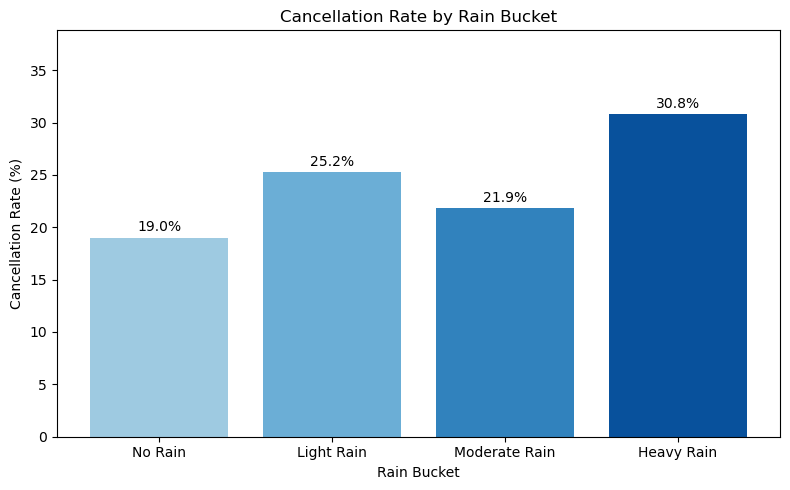

In [14]:
# Plot cancellation rate by rain bucket
plt.figure(figsize=(8, 5))
plt.bar(
    rain_summary["rain_bucket"].astype(str),
    rain_summary["cancellation_rate"],
    color=["#9ecae1", "#6baed6", "#3182bd", "#08519c"]
)

plt.title("Cancellation Rate by Rain Bucket")
plt.xlabel("Rain Bucket")
plt.ylabel("Cancellation Rate (%)")
plt.ylim(0, rain_summary["cancellation_rate"].max() + 8)

# Add percentage labels above the bars
for position, value in enumerate(rain_summary["cancellation_rate"]):
    plt.text(position, value + 0.6, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.savefig("cancellation_rate_by_rain.png", dpi=150)
plt.show()

### Chart 2: Cancellation Rate by Temperature Category

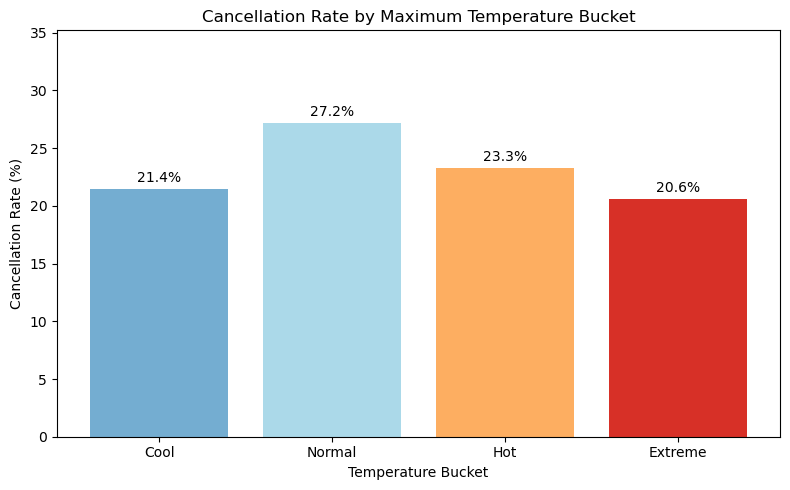

In [15]:
# Plot cancellation rate by temperature bucket
plt.figure(figsize=(8, 5))
plt.bar(
    temperature_summary["temperature_bucket"].astype(str),
    temperature_summary["cancellation_rate"],
    color=["#74add1", "#abd9e9", "#fdae61", "#d73027"]
)

plt.title("Cancellation Rate by Maximum Temperature Bucket")
plt.xlabel("Temperature Bucket")
plt.ylabel("Cancellation Rate (%)")
plt.ylim(0, temperature_summary["cancellation_rate"].max() + 8)

# Add percentage labels above the bars
for position, value in enumerate(temperature_summary["cancellation_rate"]):
    plt.text(position, value + 0.6, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.savefig("cancellation_rate_by_temperature.png", dpi=150)
plt.show()

### Compare Weather Effects

Compare the variation in cancellation rates across rainfall and temperature categories.

In [16]:
# Calculate the spread in cancellation rates for each variable
rain_rate_spread = (
    rain_summary["cancellation_rate"].max()
    - rain_summary["cancellation_rate"].min()
)

temperature_rate_spread = (
    temperature_summary["cancellation_rate"].max()
    - temperature_summary["cancellation_rate"].min()
)

print(f"Rain-bucket cancellation-rate spread: {rain_rate_spread:.2f} percentage points")
print(f"Temperature-bucket cancellation-rate spread: {temperature_rate_spread:.2f} percentage points")

if rain_rate_spread > temperature_rate_spread:
    print("Rain appears more strongly associated with cancellations.")
elif temperature_rate_spread > rain_rate_spread:
    print("Temperature appears more strongly associated with cancellations.")
else:
    print("The two variables have the same cancellation-rate spread.")

Rain-bucket cancellation-rate spread: 11.78 percentage points
Temperature-bucket cancellation-rate spread: 6.63 percentage points
Rain appears more strongly associated with cancellations.


### Heavy Rain Analysis

Compare cancellation behavior on heavy-rain days versus all other days.

In [17]:
# Create a simple heavy-rain flag
analysis_df["heavy_rain_day"] = (
    analysis_df["precipitation_sum"] > 10
)

# Compare heavy-rain days with all other days
heavy_rain_comparison = (
    analysis_df
    .groupby("heavy_rain_day")
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum"),
        cancellation_rate=("is_cancelled", "mean"),
        no_shows=("is_no_show", "sum"),
        no_show_rate=("is_no_show", "mean")
    )
)

heavy_rain_comparison["cancellation_rate"] *= 100
heavy_rain_comparison["no_show_rate"] *= 100

other_day_rate = heavy_rain_comparison.loc[
    False, "cancellation_rate"
]
heavy_rain_rate = heavy_rain_comparison.loc[
    True, "cancellation_rate"
]
heavy_rain_difference = heavy_rain_rate - other_day_rate

print(heavy_rain_comparison.round(2))
print()
print(
    f"Heavy-rain cancellation rate: {heavy_rain_rate:.2f}%"
)
print(
    f"Other-day cancellation rate: {other_day_rate:.2f}%"
)
print(
    f"Difference: {heavy_rain_difference:.2f} percentage points"
)

                bookings  cancellations  cancellation_rate  no_shows  \
heavy_rain_day                                                         
False               1160            248              21.38        32   
True                 422            130              30.81         9   

                no_show_rate  
heavy_rain_day                
False                   2.76  
True                    2.13  

Heavy-rain cancellation rate: 30.81%
Other-day cancellation rate: 21.38%
Difference: 9.43 percentage points


### City-Level Comparison

Check whether the rainfall pattern differs between Goa and Manali.

In [18]:
# Compare heavy-rain cancellation rates within each city
city_rain_summary = (
    analysis_df
    .groupby(["property_city", "heavy_rain_day"])
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum"),
        cancellation_rate=("is_cancelled", "mean")
    )
)

city_rain_summary["cancellation_rate"] *= 100
city_rain_summary.round(2)

bookings  cancellations  cancellation_rate
property_city heavy_rain_day                                            
Goa           False                636            138              21.70
              True                 240             90              37.50
Manali        False                524            110              20.99
              True                 182             40              21.98

## Key Insight

Across 1,582 valid bookings from Goa and Manali, bookings on heavy-rain days had a cancellation rate of 30.81%, compared with 21.38% on days with lower rainfall.

This represents a difference of 9.43 percentage points. Rainfall showed a stronger relationship with cancellations than temperature in this sample.

The effect was particularly visible in Goa, where cancellation rates increased noticeably during heavy-rain periods.

These findings indicate that weather conditions, especially rainfall, may influence booking behaviour and should be considered when designing cancellation policies or customer communication strategies.

## README

1. **What it does:** Enriches 2024 Goa and Manali hotel bookings with Open-Meteo historical weather and compares cancellation/no-show rates.
2. **How to run:** Place `hotel_bookings (1).csv` beside the notebook and open the notebook in Jupyter.
3. **Dependencies:** Install or provide `pandas`, `requests`, and `matplotlib`, then run all cells from top to bottom.
4. **API:** The notebook calls the free Open-Meteo Historical Weather API; no API key is required.
5. **Design decision:** Requests are batched once per city over the needed date range, then reduced to unique city-date merge keys.
6. **Limitation:** The analysis shows association, not causation, and each city is represented by one approximate coordinate.

## AI Usage Note

1. AI helped translate the problem requirements into a notebook structure.
2. AI suggested the Open-Meteo request parameters and city-date merge keys.
3. I verified the endpoint, coordinates, requested fields, and returned JSON structure.
4. I corrected date parsing so API dates and booking check-in dates use the same datatype.
5. I added timeout, HTTP-status, missing-data, and request-exception handling.
6. I verified that the merge preserved all 1,582 booking rows without duplicate expansion.
7. I checked the bucket thresholds and recalculated all reported rates from the merged data.
8. I reviewed the final charts and limited the conclusion to association rather than causation.